KNN 

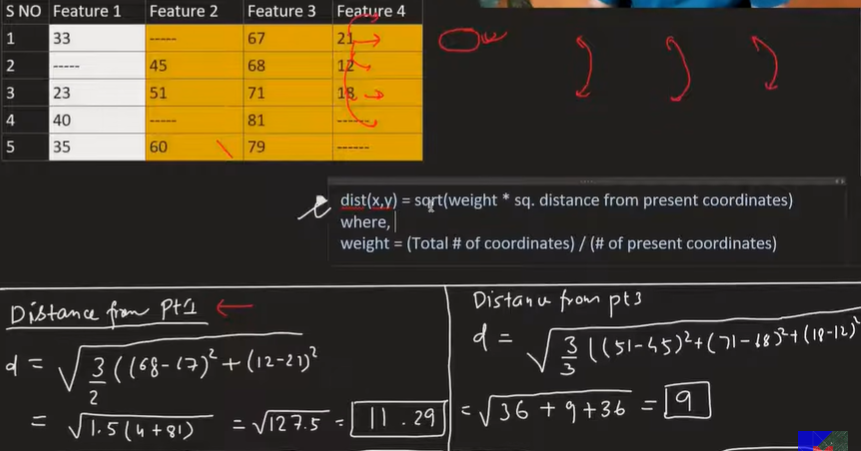

Above is the formula to find distance b/w required row and it neighbour rows.

KNN finds distance b/w required row and all remaining rows and then picks K nearest rows and average of those columns will be replaced in place of missing value.


In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Pclass','Survived'])

In [6]:
df.head()

,Survived,Pclass,Age,Fare
0,0,3,22.0,7.2500
1,1,1,38.0,71.2833
2,1,3,26.0,7.9250
3,1,1,35.0,53.1000
4,0,3,35.0,8.0500


In [7]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train.head()

,Pclass,Age,Fare
30,1,40.0,27.7208
10,3,4.0,16.7000
873,3,47.0,9.0000
182,3,9.0,31.3875
876,3,20.0,9.8458


In [25]:
knn = KNNImputer(n_neighbors=3,weights='distance') 
#By default weights='uniform'(we are taking average of weights of nearest K neighbours)
#If we set weights as distance, nearest neighbour will have more weightage compared to far neighbour.
X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

In [26]:
pd.DataFrame(X_train_trf,columns=X_train.columns)

,Pclass,Age,Fare
0,1.0,40.000000,27.7208
1,3.0,4.000000,16.7000
2,3.0,47.000000,9.0000
3,3.0,9.000000,31.3875
4,3.0,20.000000,9.8458
...,...,...,...
707,3.0,30.000000,8.6625
708,3.0,26.151292,8.7125
709,1.0,71.000000,49.5042
710,1.0,32.666667,221.7792


In [27]:
lr = LogisticRegression()
lr.fit(X_train_trf,y_train)
y_pred = lr.predict(X_test_trf)
accuracy_score(y_test,y_pred)

0.7150837988826816

In [14]:
#Compare it with mean imputation
si = SimpleImputer()
X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)
lr.fit(X_train_trf2,y_train)
y_pred2 = lr.predict(X_test_trf2)

accuracy_score(y_test,y_pred2)

0.6927374301675978